# Linear Regression

Linear Regression is a supervised machine learning algorithm used to
predict a continuous numerical target.

It tries to find the best relationship between input features and a
continuous target variable.

For a simple linear regression:

y = mx + c

Where:

y → Predicted value
x → Input feature
m → Slope / coefficient
c → Intercept

The goal is to find the values of m and c that produce predictions
as close as possible to the actual values.

## Real-World Dataset

For this notebook, we will use the Seaborn `tips` dataset.

The dataset contains information about restaurant bills and tips.

Important columns include:

- total_bill
- tip
- sex
- smoker
- day
- time
- size

Our goal is to predict:

`tip`

using:

`total_bill`

This is a regression problem because `tip` is a continuous numerical
value.

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [18]:
df.shape

(244, 7)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [20]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [21]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will use:

Feature (X):
`total_bill`

Target (y):
`tip`

We want the model to learn:

total_bill → tip

In [22]:
X = df[["total_bill"]]

y = df["tip"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (244, 1)
y shape: (244,)


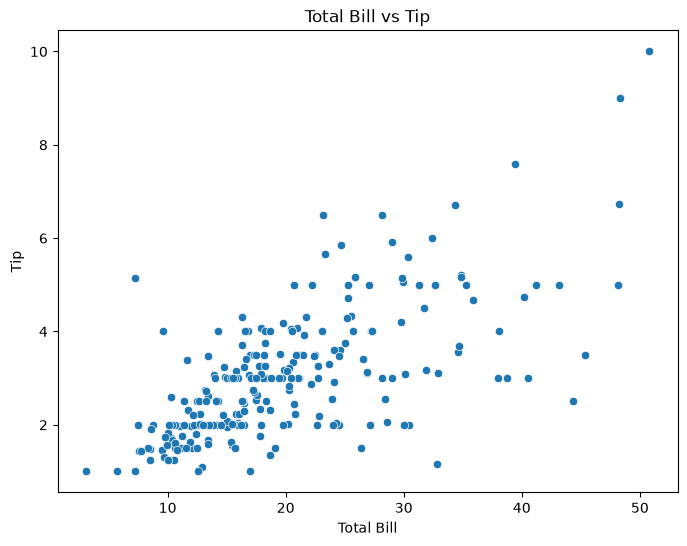

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

## Train-Test Split

We divide the dataset into:

- Training data → used to train the model
- Testing data → used to evaluate the model

We will use:

80% → Training
20% → Testing

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (195, 1)
Testing data: (49, 1)


In [25]:
model = LinearRegression()

## Training the Linear Regression Model

The model learns the relationship between:

`total_bill`

and

`tip`

using the training data.

In [26]:
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.11]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['total_bill']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9252
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


## Model Coefficient

The coefficient represents how much the predicted target changes when
the input feature increases by one unit.

For this model:

tip = coefficient × total_bill + intercept

In [27]:
print("Coefficient:", model.coef_[0])

Coefficient: 0.10696370685268666


In [28]:
print("Intercept:", model.intercept_)

Intercept: 0.9252355585570546


In [29]:
print(
    f"Tip = {model.coef_[0]:.2f} × Total Bill "
    f"+ {model.intercept_:.2f}"
)

Tip = 0.11 × Total Bill + 0.93


In [30]:
y_pred = model.predict(
    X_test
)

In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,3.045256
1,2.00,1.863307
2,2.00,3.551195
3,5.16,3.694526
4,2.00,2.315764
5,2.00,2.838816
6,2.56,3.967283
7,2.52,2.260143
8,3.23,2.506159
9,3.00,2.570337


## Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and
predicted values.

Formula:

MAE = (1/n) Σ |y - ŷ|

Lower MAE means better predictions.

In [32]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.6208580000398983


## Mean Squared Error (MSE)

MSE calculates the average squared difference between actual and
predicted values.

Formula:

MSE = (1/n) Σ (y - ŷ)²

Larger errors receive a larger penalty because the errors are squared.

Lower MSE is better.

In [33]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.5688142529229538


## Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

Formula:

RMSE = √MSE

RMSE is useful because it is expressed in the same units as the target
variable.

Lower RMSE is better.

In [34]:
import numpy as np

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.7541977545199626


## R² Score

R² measures how much of the variation in the target variable is
explained by the model.

R² can be interpreted as:

R² = 1

Perfect prediction.

R² = 0

The model explains no more variance than predicting the mean.

Higher R² is generally better.

In [35]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.5449381659234663


In [36]:
print("Model Performance")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
-----------------
MAE : 0.6208580000398983
MSE : 0.5688142529229538
RMSE: 0.7541977545199626
R²  : 0.5449381659234663


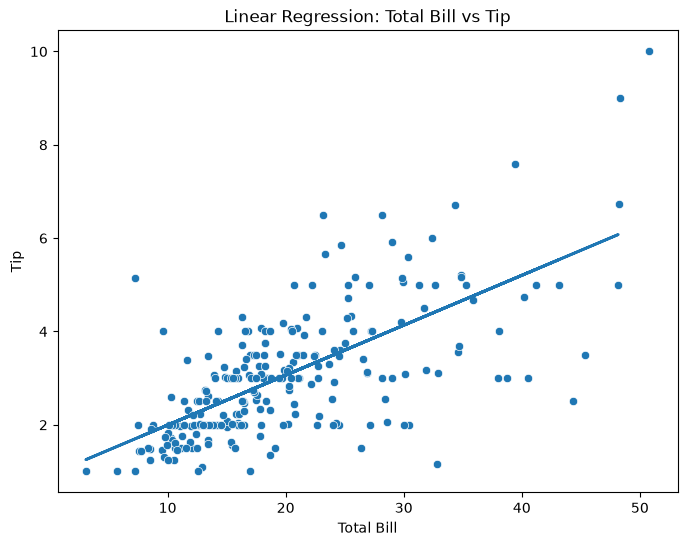

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.plot(
    X_test,
    y_pred,
    linewidth=2
)

plt.title("Linear Regression: Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

## Residuals

A residual is the difference between the actual value and the
predicted value.

Residual:

e = y - ŷ

Where:

y → Actual value
ŷ → Predicted value

A good regression model generally has residuals that are centered
around zero without obvious patterns.

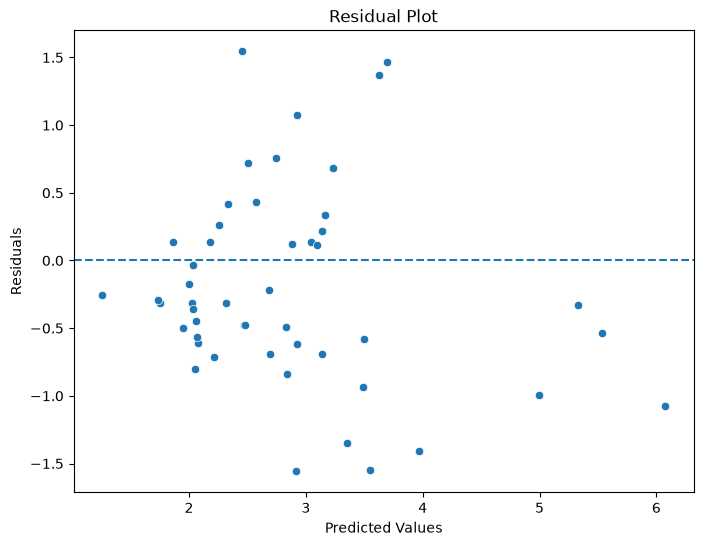

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [39]:
new_bill = pd.DataFrame({
    "total_bill": [50]
})

prediction = model.predict(
    new_bill
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 6.273420901191388


## Linear Regression Assumptions

Important assumptions include:

1. Linearity
   The relationship between features and target should be approximately
   linear.

2. Independence
   Observations should generally be independent.

3. Homoscedasticity
   The variance of residuals should be reasonably constant.

4. Normality of Residuals
   Residuals are often expected to be approximately normally distributed
   for statistical inference.

5. Low Multicollinearity
   In multiple linear regression, predictors should not be highly
   correlated with each other.